In [1]:
# ==============================
#  DERMATOLOGY AI PROJECT SETUP
# ==============================

import os
import zipfile
import numpy as np
import tensorflow as tf
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define project path
PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# ZIP file paths
ISIC_ZIP = f"{DATASET_PATH}/ISIC2018_segmentation.zip"
HAM_ZIP = f"{DATASET_PATH}/HAM10000.zip"

print("Project Path:", PROJECT_PATH)
print("Dataset Path:", DATASET_PATH)

# Move to project directory
os.chdir(PROJECT_PATH)
print("Current Working Directory:", os.getcwd())

Mounting Google Drive...
Mounted at /content/drive
Project Path: /content/drive/MyDrive/Dermatology_AI_Project
Dataset Path: /content/drive/MyDrive/Dermatology_AI_Project/datasets
Current Working Directory: /content/drive/MyDrive/Dermatology_AI_Project


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

In [3]:
model_path = "/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_finetuned_final.keras"

classifier_model = tf.keras.models.load_model(model_path)

print("Model Loaded Successfully")

Model Loaded Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 31 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
class_names = [
    "melanoma",
    "melanocytic nevus",
    "basal cell carcinoma",
    "actinic keratosis",
    "benign keratosis",
    "dermatofibroma",
    "vascular lesion"
]

In [5]:
# Risk Mapping

risk_levels = {
    "melanoma": "HIGH",
    "basal cell carcinoma": "HIGH",
    "actinic keratosis": "MEDIUM",
    "benign keratosis": "LOW",
    "dermatofibroma": "LOW",
    "melanocytic nevus": "LOW",
    "vascular lesion": "LOW"
}

In [6]:
recommendations = {
    "melanoma": "Immediate dermatologist consultation and biopsy recommended.",
    "basal cell carcinoma": "Dermatologist consultation recommended.",
    "actinic keratosis": "Monitor lesion and consider topical treatment.",
    "benign keratosis": "Usually harmless but monitor for changes.",
    "dermatofibroma": "Typically benign, routine monitoring suggested.",
    "melanocytic nevus": "Regular monitoring advised.",
    "vascular lesion": "Usually benign, consult dermatologist if changes occur."
}

In [7]:
def get_risk_level(pred_class):
    return risk_levels.get(pred_class.lower(), "UNKNOWN")


def get_recommendation(pred_class):
    return recommendations.get(pred_class.lower(), "Consult dermatologist.")

In [8]:
def confidence_strength(conf):

    if conf > 0.80:
        return "STRONG"

    elif conf > 0.60:
        return "MODERATE"

    else:
        return "LOW — HUMAN REVIEW REQUIRED"

In [9]:
def generate_clinical_report(pred_class, confidence):

    risk = get_risk_level(pred_class)
    advice = get_recommendation(pred_class)
    conf_status = confidence_strength(confidence)

    report = f"""
    ===== AI Dermatology Clinical Report =====

    Predicted Condition: {pred_class}

    Model Confidence: {confidence:.2f}

    Confidence Strength: {conf_status}

    Risk Level: {risk}

    Clinical Recommendation:
    {advice}

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    """

    return report

In [10]:
pred_class = "melanoma"
confidence = 0.91

report = generate_clinical_report(pred_class, confidence)

print(report)


    ===== AI Dermatology Clinical Report =====

    Predicted Condition: melanoma

    Model Confidence: 0.91

    Confidence Strength: STRONG

    Risk Level: HIGH

    Clinical Recommendation:
    Immediate dermatologist consultation and biopsy recommended.

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    


In [12]:
IMG_SIZE = 224

def preprocess_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    return img

In [13]:
def predict_skin_lesion(image_path):

    img = preprocess_image(image_path)

    predictions = classifier_model.predict(img)

    pred_index = np.argmax(predictions)

    pred_class = class_names[pred_index]

    confidence = float(np.max(predictions))

    return pred_class, confidence

In [26]:
def diagnose_image(image_path):

    pred_class, confidence = predict_skin_lesion(image_path)

    report = generate_clinical_report(pred_class, confidence)

    print(report)

    image_name = os.path.basename(image_path).split(".")[0]

    save_clinical_report(report, image_name)

    visualize_risk(pred_class, confidence)

    return pred_class, confidence

In [27]:
image_path = "/content/drive/MyDrive/Dermatology_AI_Project/test_images/lesion.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step

    ===== AI Dermatology Clinical Report =====

    Predicted Condition: dermatofibroma

    Model Confidence: 0.97

    Confidence Strength: STRONG

    Risk Level: LOW

    Clinical Recommendation:
    Typically benign, routine monitoring suggested.

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    
Report saved at: /content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports/report_lesion.txt


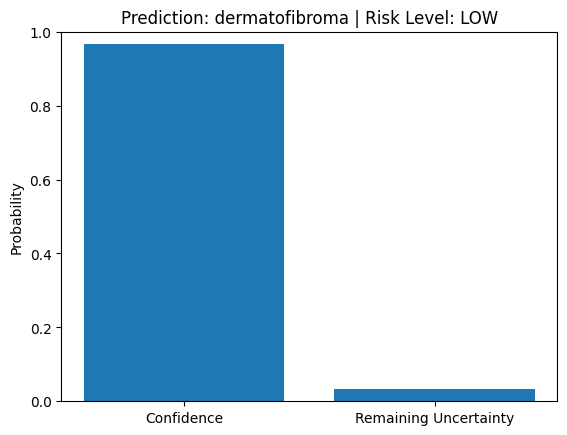

('dermatofibroma', 0.9677960872650146)

In [28]:
diagnose_image(image_path)

Text(0.5, 1.0, 'Input Skin Lesion Image')

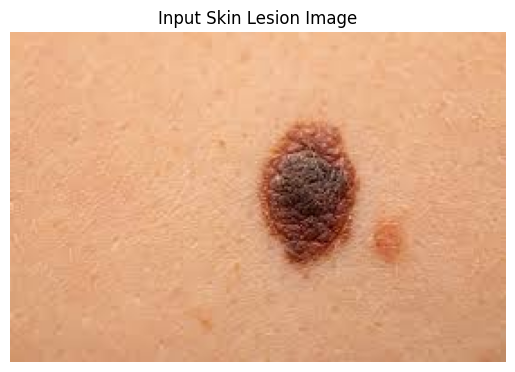

In [29]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Input Skin Lesion Image")

In [30]:
import os

report_dir = "/content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports"

os.makedirs(report_dir, exist_ok=True)

print("Report directory ready:", report_dir)

Report directory ready: /content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports


In [31]:
def save_clinical_report(report_text, image_name):

    report_path = os.path.join(
        report_dir,
        f"report_{image_name}.txt"
    )

    with open(report_path, "w") as f:
        f.write(report_text)

    print("Report saved at:", report_path)

In [32]:
def visualize_risk(pred_class, confidence):

    risk = get_risk_level(pred_class)

    labels = ["Confidence", "Remaining Uncertainty"]
    values = [confidence, 1 - confidence]

    plt.figure()

    plt.bar(labels, values)

    plt.title(f"Prediction: {pred_class} | Risk Level: {risk}")

    plt.ylabel("Probability")

    plt.ylim(0,1)

    plt.show()

In [33]:
def show_probability_distribution(predictions):

    probs = predictions[0]

    plt.figure()

    plt.bar(class_names, probs)

    plt.xticks(rotation=45)

    plt.ylabel("Probability")

    plt.title("Prediction Probability Distribution")

    plt.show()

In [34]:
def confidence_gauge(confidence):

    plt.figure()

    plt.barh(["Confidence"], [confidence])

    plt.xlim(0,1)

    plt.title(f"Model Confidence Gauge: {confidence:.2f}")

    plt.xlabel("Confidence Score")

    plt.show()

In [35]:
import pandas as pd

log_path = "/content/drive/MyDrive/Dermatology_AI_Project/results/diagnosis_log.csv"

def log_diagnosis(image_name, pred_class, confidence, risk):

    data = {
        "Image": image_name,
        "Prediction": pred_class,
        "Confidence": confidence,
        "Risk": risk
    }

    df = pd.DataFrame([data])

    if os.path.exists(log_path):
        df.to_csv(log_path, mode='a', header=False, index=False)
    else:
        df.to_csv(log_path, index=False)

    print("Diagnosis logged to CSV")

In [36]:
def diagnose_folder(folder_path):

    images = os.listdir(folder_path)

    for img in images:

        img_path = os.path.join(folder_path, img)

        print("\nProcessing:", img)

        diagnose_image(img_path)


Processing: lesion.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step

    ===== AI Dermatology Clinical Report =====

    Predicted Condition: dermatofibroma

    Model Confidence: 0.97

    Confidence Strength: STRONG

    Risk Level: LOW

    Clinical Recommendation:
    Typically benign, routine monitoring suggested.

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    
Report saved at: /content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports/report_lesion.txt


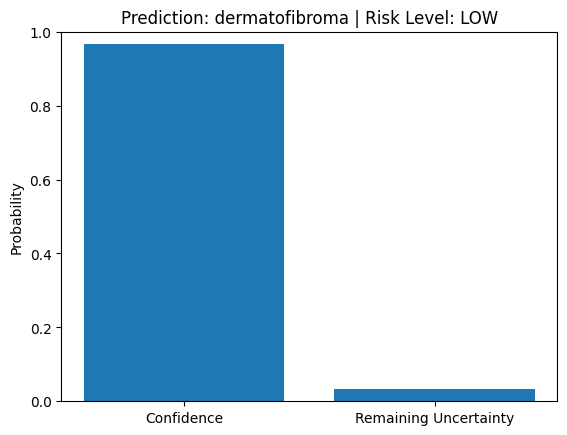


Processing: lesion2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step

    ===== AI Dermatology Clinical Report =====

    Predicted Condition: dermatofibroma

    Model Confidence: 0.53

    Confidence Strength: LOW — HUMAN REVIEW REQUIRED

    Risk Level: LOW

    Clinical Recommendation:
    Typically benign, routine monitoring suggested.

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    
Report saved at: /content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports/report_lesion2.txt


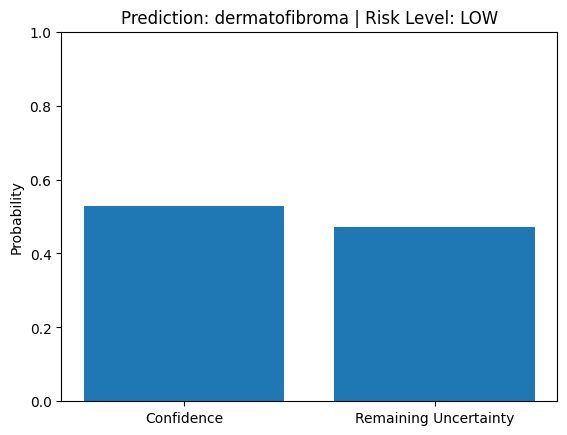

In [37]:
diagnose_folder("/content/drive/MyDrive/Dermatology_AI_Project/test_images")

In [38]:
def predict_skin_lesion(image_path):

    img = preprocess_image(image_path)

    predictions = classifier_model.predict(img)

    pred_index = np.argmax(predictions)

    pred_class = class_names[pred_index]

    confidence = float(np.max(predictions))

    return pred_class, confidence, predictions

In [41]:
def diagnose_image(image_path):

    # Show input image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Skin Lesion Image")
    plt.show()

    # Prediction
    pred_class, confidence, predictions = predict_skin_lesion(image_path)

    # Generate report
    report = generate_clinical_report(pred_class, confidence)

    print(report)

    image_name = os.path.basename(image_path)

    risk = get_risk_level(pred_class)

    # Save report
    save_clinical_report(report, image_name)

    # Log to CSV
    log_diagnosis(image_name, pred_class, confidence, risk)

    # Visualizations
    show_probability_distribution(predictions)

    confidence_gauge(confidence)

    visualize_risk(pred_class, confidence)

    return pred_class, confidence

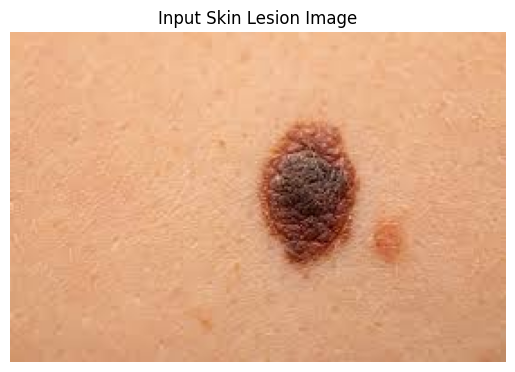

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step

    ===== AI Dermatology Clinical Report =====

    Predicted Condition: dermatofibroma

    Model Confidence: 0.97

    Confidence Strength: STRONG

    Risk Level: LOW

    Clinical Recommendation:
    Typically benign, routine monitoring suggested.

    Disclaimer:
    AI system is for clinical decision support only.
    Final diagnosis must be confirmed by a dermatologist.
    
Report saved at: /content/drive/MyDrive/Dermatology_AI_Project/results/clinical_reports/report_lesion.jpg.txt
Diagnosis logged to CSV


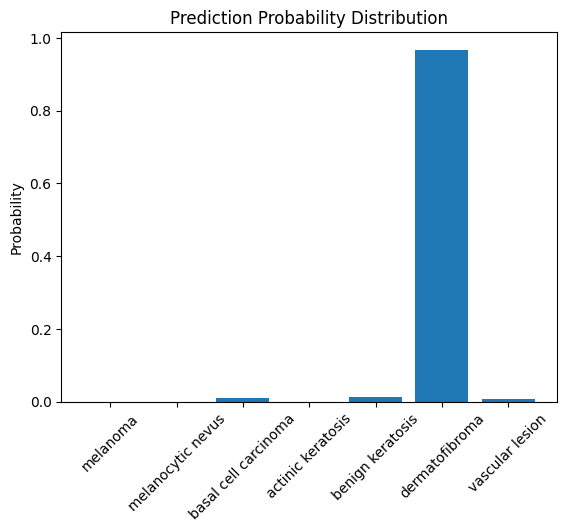

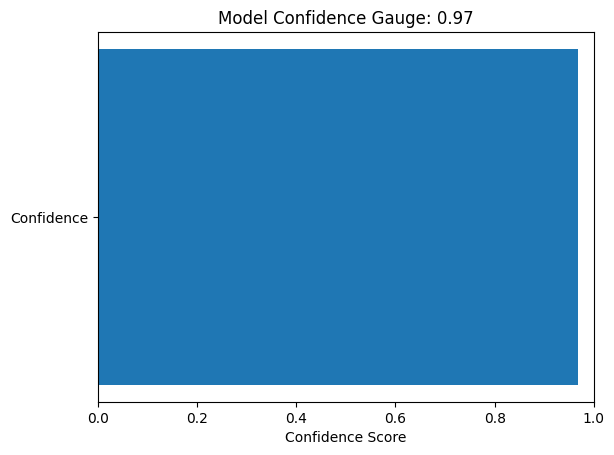

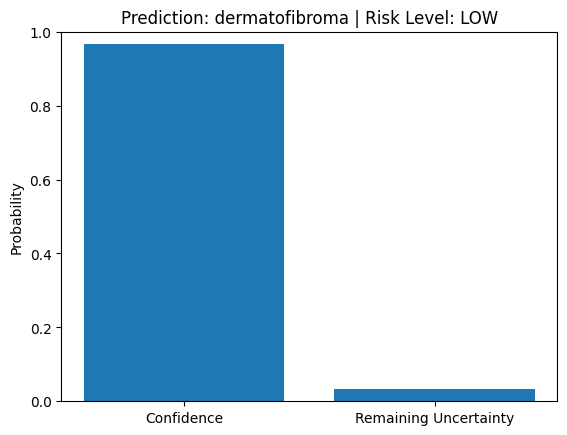

('dermatofibroma', 0.9677960872650146)

In [42]:
diagnose_image(image_path)